In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import os

sns.set_theme(style="whitegrid")

os.makedirs("reports/charts", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

print("Setup done")

Setup done


In [15]:
fund_master = pd.read_csv("data/processed/01_fund_master_cleaned.csv")
nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")
benchmark = pd.read_csv("data/processed/10_benchmark_indices_cleaned.csv")
performance = pd.read_csv("data/processed/07_scheme_performance_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

print(nav.shape)
print(nav.head())

print("\nBenchmark columns:")
print(benchmark.columns.tolist())
print(benchmark.head())

(46000, 3)
   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639

Benchmark columns:
['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [16]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav_returns = nav.dropna(subset=["daily_return"])

print(nav_returns["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [17]:
def calculate_cagr(group, years):
    group = group.sort_values("date")
    
    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)
    
    filtered = group[group["date"] >= start_date]
    
    if len(filtered) < 2:
        return np.nan
    
    nav_start = filtered.iloc[0]["nav"]
    nav_end = filtered.iloc[-1]["nav"]
    
    if nav_start <= 0:
        return np.nan
    
    return ((nav_end / nav_start) ** (1 / years)) - 1

In [18]:
cagr_rows = []

for code, group in nav.groupby("amfi_code"):
    cagr_rows.append({
        "amfi_code": code,
        "cagr_1yr": calculate_cagr(group, 1),
        "cagr_3yr": calculate_cagr(group, 3),
        "cagr_5yr": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_rows)

cagr_df = cagr_df.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "category", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name,fund_house,category,expense_ratio_pct
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,1.55
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,0.56
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,1.38
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,1.60
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,1.53


In [19]:
rf_annual = 0.065
rf_daily = rf_annual / 252

risk_rows = []

for code, group in nav_returns.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    
    avg_daily_return = returns.mean()
    std_daily_return = returns.std()
    
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    
    sharpe = ((avg_daily_return - rf_daily) / std_daily_return) * np.sqrt(252) if std_daily_return != 0 else np.nan
    
    sortino = ((avg_daily_return - rf_daily) / downside_std) * np.sqrt(252) if downside_std != 0 else np.nan
    
    risk_rows.append({
        "amfi_code": code,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino
    })

risk_df = pd.DataFrame(risk_rows)

risk_df.head()

,amfi_code,sharpe_ratio,sortino_ratio
0,100016,-0.201517,-0.351047
1,100025,-0.567095,-0.941821
2,100033,1.093699,1.829134
3,101206,1.027213,1.799563
4,101207,0.162661,0.276644


In [20]:
drawdown_rows = []

for code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date").copy()
    
    group["running_max"] = group["nav"].cummax()
    group["drawdown"] = (group["nav"] / group["running_max"]) - 1
    
    max_dd = group["drawdown"].min()
    max_dd_date = group.loc[group["drawdown"].idxmin(), "date"]
    
    drawdown_rows.append({
        "amfi_code": code,
        "max_drawdown": max_dd,
        "max_drawdown_date": max_dd_date
    })

drawdown_df = pd.DataFrame(drawdown_rows)

drawdown_df.head()

,amfi_code,max_drawdown,max_drawdown_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [21]:
benchmark.columns.tolist()

['date', 'index_name', 'close_value']

In [22]:
scorecard = cagr_df.merge(risk_df, on="amfi_code", how="left")
scorecard = scorecard.merge(drawdown_df, on="amfi_code", how="left")

scorecard.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name,fund_house,category,expense_ratio_pct,sharpe_ratio,sortino_ratio,max_drawdown,max_drawdown_date
0,100016,-0.022243,0.012926,0.023168,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,1.55,-0.201517,-0.351047,-0.247344,2022-09-15
1,100025,0.037050,0.039164,0.039127,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,0.56,-0.567095,-0.941821,-0.043083,2023-07-28
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,1.38,1.093699,1.829134,-0.162172,2022-05-12
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,1.60,1.027213,1.799563,-0.112916,2023-07-05
4,101207,-0.239860,-0.041524,0.069533,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,1.53,0.162661,0.276644,-0.354469,2026-05-11


In [23]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [27]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

print(nifty100.shape)
nifty100.head()

(1150, 4)


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [28]:
alpha_beta_rows = []

for code, group in nav_returns.groupby("amfi_code"):

    merged = pd.merge(
        group[["date", "daily_return"]],
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    beta, alpha, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_rows.append({
        "amfi_code": code,
        "alpha": alpha * 252,
        "beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [29]:
alpha_beta_df.to_csv(
    "data/processed/alpha_beta.csv",
    index=False
)

print("Saved alpha_beta.csv")

Saved alpha_beta.csv


In [30]:
scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code",
    how="left"
)

scorecard["return_rank"] = scorecard["cagr_3yr"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["drawdown_rank"] * 0.10
)

scorecard = scorecard.sort_values("fund_score")

scorecard.to_csv("data/processed/fund_scorecard.csv", index=False)

scorecard.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name,fund_house,category,expense_ratio_pct,sharpe_ratio,sortino_ratio,max_drawdown,max_drawdown_date,alpha,beta,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
34,148567,0.203607,0.340009,0.267993,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,1.46,1.448291,2.385644,-0.112657,2023-10-20,0.269838,0.023684,2.0,1.0,7.0,23.0,8.0,6.500
25,120505,0.296047,0.317775,0.283768,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,1.36,1.180101,2.029353,-0.181885,2025-01-23,0.292636,0.000549,5.0,5.0,3.0,15.0,25.0,8.100
30,120843,0.266571,0.295828,0.267425,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,1.45,1.306744,2.364320,-0.129740,2022-04-13,0.273305,-0.022830,7.0,2.0,5.0,22.0,13.0,8.200
2,100033,0.532324,0.324425,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,1.38,1.093699,1.829134,-0.162172,2022-05-12,0.271954,0.005104,4.0,7.0,6.0,17.0,20.0,8.700
24,120504,0.130643,0.324874,0.202340,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.80,1.026524,1.805294,-0.125883,2023-05-30,0.211948,0.016232,3.0,10.0,13.0,12.0,12.0,9.000
16,119094,0.222611,0.351118,0.244453,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,1.38,0.998231,1.703797,-0.209609,2022-08-11,0.260767,-0.066265,1.0,11.0,9.0,17.0,28.0,10.200
19,119551,0.604373,0.304565,0.223849,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,1.54,1.208267,2.140267,-0.150124,2024-02-05,0.232010,-0.031751,6.0,4.0,10.0,30.5,17.0,11.075
36,148569,0.397518,0.291789,0.276299,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,1.60,1.234930,2.146914,-0.163967,2023-10-20,0.282704,0.018134,8.0,3.0,4.0,36.5,21.0,11.525
3,101206,0.479241,0.289677,0.204427,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,1.60,1.027213,1.799563,-0.112916,2023-07-05,0.213998,0.021086,9.0,9.0,12.0,36.5,9.0,13.725
21,119598,0.827761,0.266699,0.280332,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,1.43,0.945308,1.675317,-0.287060,2025-05-14,0.303370,-0.023196,12.0,14.0,1.0,21.0,36.0,14.050


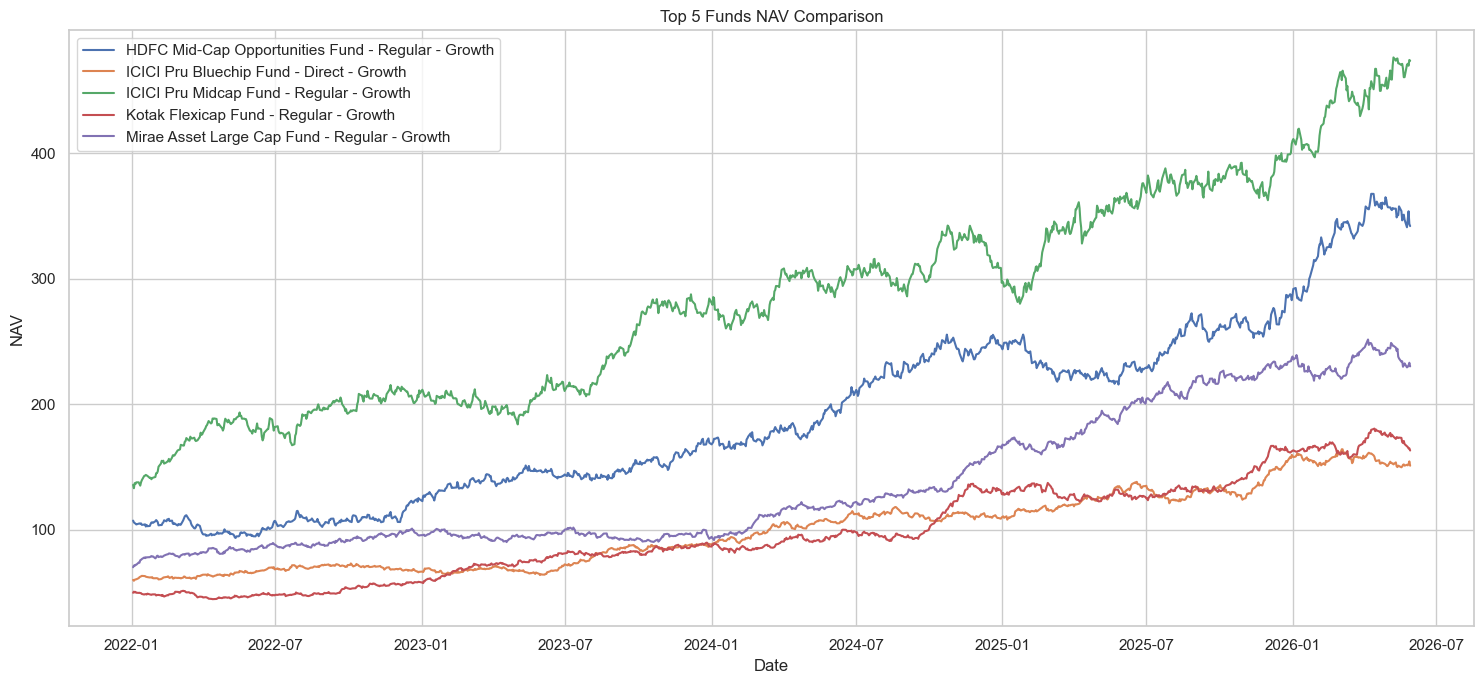

In [31]:
top5 = scorecard.head(5)["amfi_code"].tolist()

top5_nav = nav[nav["amfi_code"].isin(top5)].copy()

top5_nav = top5_nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

plt.figure(figsize=(15, 7))

for scheme in top5_nav["scheme_name"].unique():
    temp = top5_nav[top5_nav["scheme_name"] == scheme]
    plt.plot(temp["date"], temp["nav"], label=scheme)

plt.title("Top 5 Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.tight_layout()

plt.savefig("reports/charts/benchmark_comparison.png", dpi=300)
plt.show()

In [32]:
import os

print(os.path.exists("data/processed/fund_scorecard.csv"))
print(os.path.exists("data/processed/alpha_beta.csv"))
print(os.path.exists("reports/charts/benchmark_comparison.png"))

True
True
True
